# Step 3 - Train Symbol Classifier (CNN)

Train a CNN to recognize handwritten math symbols from 45x45 grayscale images.

Run this on **Google Colab with T4 GPU**.

Dataset: HASYv2 - 168,000+ images of 369 symbol classes. We only use a subset of classes relevant to math equations.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print(f'TF version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TF version: 2.20.0
GPU available: []


## Download HASYv2 dataset

In [6]:
# download and extract
!wget -q https://zenodo.org/records/259444/files/HASYv2.tar.bz2
!mkdir -p HASYv2
!tar -xjf HASYv2.tar.bz2 -C HASYv2
!ls HASYv2/
print('done')

classification-task  hasy-data-labels.csv  README.txt	verification-task
hasy-data	     hasy_tools.py	   symbols.csv
done


In [7]:
# load the symbol mapping
symbols_df = pd.read_csv('HASYv2/symbols.csv')
print(f'total classes in dataset: {len(symbols_df)}')
symbols_df.head(10)

total classes in dataset: 369


,symbol_id,latex,training_samples,test_samples
0,31,A,137,22
1,32,B,53,8
2,33,C,120,14
3,34,D,50,8
4,35,E,48,6
5,36,F,50,6
6,37,G,106,12
7,38,H,57,7
8,39,I,90,10
9,40,J,93,11


## Filter to math symbols we care about

HASYv2 has 369 classes including greek letters, arrows, etc. We only need:
- digits: 0-9
- operators: + - Ã— Ã· =
- variables: x y
- brackets: ( )

In [ ]:
# symbols we want, latex names from HASYv2
target_symbols = {
    '0': '\\0',  '1': '\\1',  '2': '\\2',  '3': '\\3',  '4': '\\4',
    '5': '\\5',  '6': '\\6',  '7': '\\7',  '8': '\\8',  '9': '\\9',
    '+': '\\+',  '-': '\\-',  '=': '\\=',
    'x': '\\x',  'y': '\\y',
    '(': '\\(',  ')': '\\)',
    'times': '\\times', 'div': '\\div',
}

# HASYv2 uses latex_symbol column, let's see what's actually in there
print('looking for our symbols...')
data_df = pd.read_csv('HASYv2/hasy-data-labels.csv')
print(f'total images: {len(data_df)}')
print(f'columns: {list(data_df.columns)}')
data_df.head()

looking for our symbols...
total images: 168233
columns: ['path', 'symbol_id', 'latex', 'user_id']


,path,symbol_id,latex,user_id
0,hasy-data/v2-00000.png,31,A,50
1,hasy-data/v2-00001.png,31,A,10
2,hasy-data/v2-00002.png,31,A,43
3,hasy-data/v2-00003.png,31,A,43
4,hasy-data/v2-00004.png,31,A,4435


In [9]:
# check what symbol ids map to our target symbols
# first, lets see the mapping
id_to_latex = dict(zip(symbols_df['symbol_id'], symbols_df['latex']))
latex_to_id = dict(zip(symbols_df['latex'], symbols_df['symbol_id']))

# find our symbols in the dataset
our_labels = {}
for name, latex in target_symbols.items():
    if latex in latex_to_id:
        sid = latex_to_id[latex]
        count = len(data_df[data_df['symbol_id'] == sid])
        our_labels[name] = sid
        print(f'{name:6s} -> latex: {latex:10s} -> id: {sid:4d} -> count: {count}')
    else:
        print(f'{name:6s} -> latex: {latex:10s} -> NOT FOUND')

print(f'\nfound {len(our_labels)} out of {len(target_symbols)} symbols')

0      -> latex: \0         -> NOT FOUND
1      -> latex: \1         -> NOT FOUND
2      -> latex: \2         -> NOT FOUND
3      -> latex: \3         -> NOT FOUND
4      -> latex: \4         -> NOT FOUND
5      -> latex: \5         -> NOT FOUND
6      -> latex: \6         -> NOT FOUND
7      -> latex: \7         -> NOT FOUND
8      -> latex: \8         -> NOT FOUND
9      -> latex: \9         -> NOT FOUND
+      -> latex: \+         -> NOT FOUND
-      -> latex: \-         -> NOT FOUND
=      -> latex: \=         -> NOT FOUND
x      -> latex: \x         -> NOT FOUND
y      -> latex: \y         -> NOT FOUND
(      -> latex: \(         -> NOT FOUND
)      -> latex: \)         -> NOT FOUND
times  -> latex: \times     -> id:  513 -> count: 1509
div    -> latex: \div       -> id:  526 -> count: 335

found 2 out of 19 symbols


In [10]:
# fix — use actual latex names from the dataset
target_symbols = {}
for _, row in symbols_df.iterrows():
    latex = row['latex']
    if latex in ['0','1','2','3','4','5','6','7','8','9']:
        target_symbols[latex] = latex
    elif latex in ['+', '-', '=', '(', ')']:
        target_symbols[latex] = latex
    elif latex in ['x', 'y', 'X', 'Y']:
        target_symbols[latex] = latex
    elif latex in ['\\times', '\\div']:
        target_symbols[latex.replace('\\','')] = latex

print(f'target symbols: {target_symbols}')

# rebuild our_labels
our_labels = {}
for name, latex in target_symbols.items():
    if latex in latex_to_id:
        sid = latex_to_id[latex]
        count = len(data_df[data_df['symbol_id'] == sid])
        our_labels[name] = sid
        print(f'{name:6s} -> latex: {latex:10s} -> id: {sid:4d} -> count: {count}')
    else:
        print(f'{name:6s} -> NOT FOUND')

print(f'\nfound {len(our_labels)} out of {len(target_symbols)} symbols')

target symbols: {'X': 'X', 'Y': 'Y', '0': '0', '1': '1', '2': '2', '3': '3', '4': '4', '5': '5', '6': '6', '7': '7', '8': '8', '9': '9', 'x': 'x', 'y': 'y', '-': '-', '+': '+', 'times': '\\times', 'div': '\\div'}
X      -> latex: X          -> id:   54 -> count: 54
Y      -> latex: Y          -> id:   55 -> count: 56
0      -> latex: 0          -> id:   70 -> count: 133
1      -> latex: 1          -> id:   71 -> count: 118
2      -> latex: 2          -> id:   72 -> count: 124
3      -> latex: 3          -> id:   73 -> count: 120
4      -> latex: 4          -> id:   74 -> count: 61
5      -> latex: 5          -> id:   75 -> count: 78
6      -> latex: 6          -> id:   76 -> count: 100
7      -> latex: 7          -> id:   77 -> count: 75
8      -> latex: 8          -> id:   78 -> count: 121
9      -> latex: 9          -> id:   79 -> count: 90
x      -> latex: x          -> id:  113 -> count: 66
y      -> latex: y          -> id:  114 -> count: 58
-      -> latex: -          -> id:  195

In [ ]:
# after checking the output above, build the final mapping
# UPDATE these IDs based on what the previous cell prints
# this is a template, adjust symbol_ids after running on colab

target_ids = list(our_labels.values())
id_to_name = {v: k for k, v in our_labels.items()}

# filter dataset
filtered = data_df[data_df['symbol_id'].isin(target_ids)].copy()
filtered['label_name'] = filtered['symbol_id'].map(id_to_name)
print(f'filtered dataset: {len(filtered)} images across {filtered["label_name"].nunique()} classes')
print()
print(filtered['label_name'].value_counts())

filtered dataset: 3306 images across 18 classes

label_name
times    1509
div       335
0         133
2         124
8         121
3         120
-         118
1         118
6         100
9          90
+          90
5          78
7          75
x          66
4          61
y          58
Y          56
X          54
Name: count, dtype: int64


## Load images

In [ ]:
IMG_SIZE = 45

images = []
labels = []
skipped = 0

for _, row in filtered.iterrows():
    path = os.path.join('HASYv2', row['path']) if 'path' in row else None
    if path is None or not os.path.exists(path):
        skipped += 1
        continue

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        skipped += 1
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    # invert if needed, we want white symbol on black background
    if np.mean(img) > 127:
        img = 255 - img

    images.append(img)
    labels.append(row['label_name'])

print(f'loaded {len(images)} images, skipped {skipped}')

X = np.array(images, dtype=np.float32) / 255.0  # normalize to 0-1
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # add channel dim

# encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)
y = keras.utils.to_categorical(y_encoded, num_classes)

print(f'X shape: {X.shape}')
print(f'classes ({num_classes}): {list(le.classes_)}')

loaded 3306 images, skipped 0
X shape: (3306, 45, 45, 1)
classes (18): [np.str_('+'), np.str_('-'), np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('X'), np.str_('Y'), np.str_('div'), np.str_('times'), np.str_('x'), np.str_('y')]


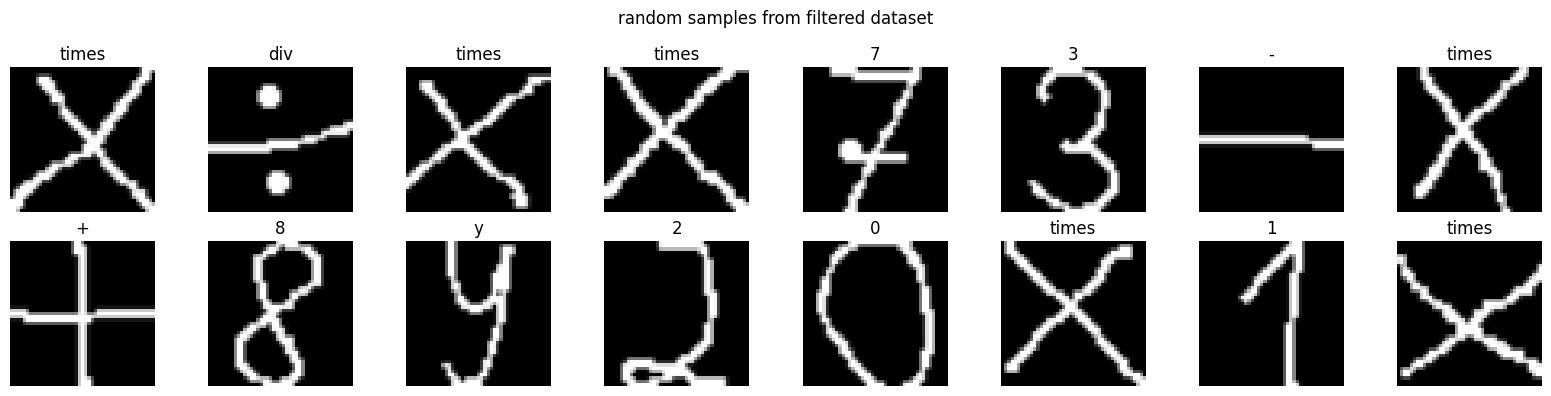

In [13]:
# show some samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X))
    ax.imshow(X[idx].squeeze(), cmap='gray')
    ax.set_title(labels[idx])
    ax.axis('off')
plt.suptitle('random samples from filtered dataset')
plt.tight_layout()
plt.show()

## Train/val split

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_encoded)
print(f'train: {X_train.shape[0]}, val: {X_val.shape[0]}')

train: 2644, val: 662


## Build CNN

Simple architecture, nothing fancy. 3 conv blocks with batch norm, then dense layers.
Input is 45x45x1 grayscale.

In [15]:
model = keras.Sequential([
    # block 1
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # classifier
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 45, 45, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 45, 45, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 45, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 965,234 (3.68 MB)

 Trainable params: 964,082 (3.68 MB)

 Non-trainable params: 1,152 (4.50 KB)

## Data augmentation

Slight rotations, shifts, zoom to make the model more robust to different handwriting styles.

In [16]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=5,
)
datagen.fit(X_train)

## Train

In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6),
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=callbacks,
)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 47s 986ms/step - accuracy: 0.6207 - loss: 1.3598 - val_accuracy: 0.0363 - val_loss: 5.2934 - learning_rate: 0.0010
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 900ms/step - accuracy: 0.8101 - loss: 0.6795 - val_accuracy: 0.0363 - val_loss: 6.6845 - learning_rate: 0.0010
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8669 - loss: 0.4921 - val_accuracy: 0.0363 - val_loss: 7.3430 - learning_rate: 0.0010
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 920ms/step - accuracy: 0.8763 - loss: 0.4477 - val_accuracy: 0.0363 - val_loss: 7.7719 - learning_rate: 0.0010
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 982ms/step - accuracy: 0.8952 - loss: 0.3869 - val_accuracy: 0.0363 - val_loss: 7.5789 - learning_rate: 0.0010
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 926ms/step - accuracy: 0.9070 - loss: 0.3435 - val_accuracy: 0.0363 - val_loss: 6.5249 - learning_rate: 0.0010
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 984ms/step - accuracy: 0.9164 - loss: 0.311

## Training curves

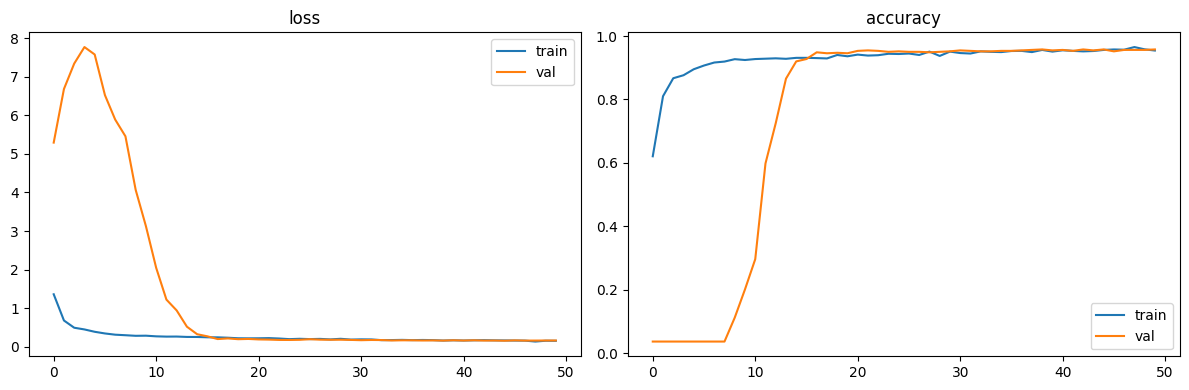

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.9577 - loss: 0.1555

val accuracy: 0.9577


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

val_loss, val_acc = model.evaluate(X_val, y_val)
print(f'\nval accuracy: {val_acc:.4f}')

## Confusion matrix

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step


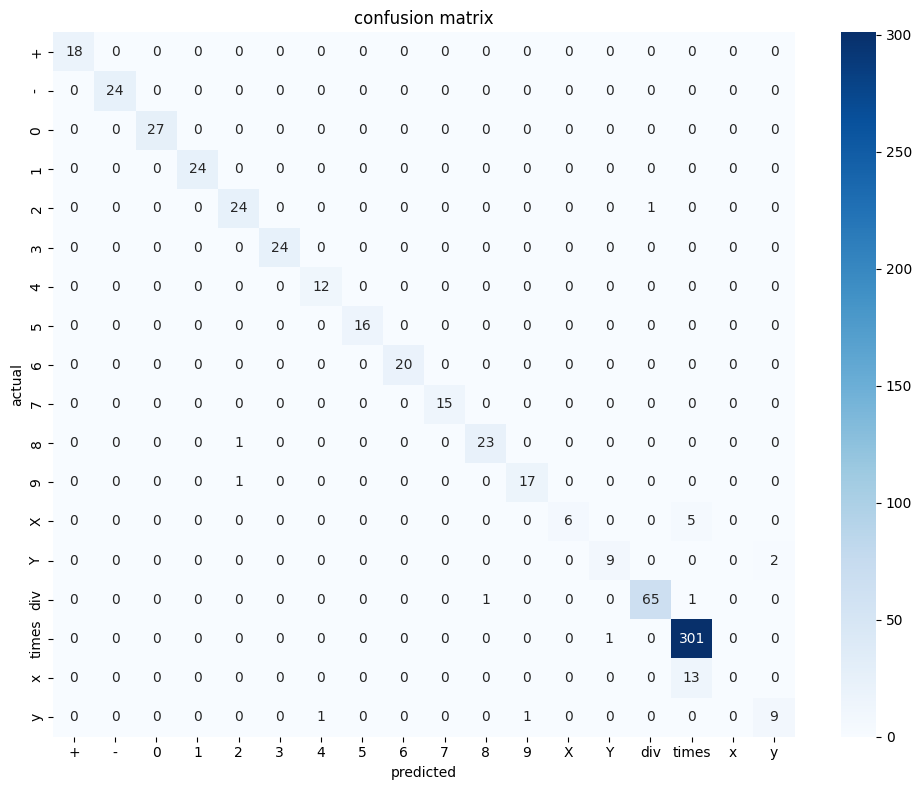

              precision    recall  f1-score   support

           +       1.00      1.00      1.00        18
           -       1.00      1.00      1.00        24
           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        24
           2       0.92      0.96      0.94        25
           3       1.00      1.00      1.00        24
           4       0.92      1.00      0.96        12
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        15
           8       0.96      0.96      0.96        24
           9       0.94      0.94      0.94        18
           X       1.00      0.55      0.71        11
           Y       0.90      0.82      0.86        11
         div       0.98      0.97      0.98        67
       times       0.94      1.00      0.97       302
           x       0.00      0.00      0.00        13
           y       0.82    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

## Save model

Save as .h5 and also the label encoder so we know which class index = which symbol.

In [20]:
import json

# save model
model.save('symbol_classifier.h5')
print('saved symbol_classifier.h5')

# save label mapping
label_map = {int(i): name for i, name in enumerate(le.classes_)}
with open('label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print('saved label_map.json')
print(f'label map: {label_map}')

saved symbol_classifier.h5
saved label_map.json
label map: {0: np.str_('+'), 1: np.str_('-'), 2: np.str_('0'), 3: np.str_('1'), 4: np.str_('2'), 5: np.str_('3'), 6: np.str_('4'), 7: np.str_('5'), 8: np.str_('6'), 9: np.str_('7'), 10: np.str_('8'), 11: np.str_('9'), 12: np.str_('X'), 13: np.str_('Y'), 14: np.str_('div'), 15: np.str_('times'), 16: np.str_('x'), 17: np.str_('y')}


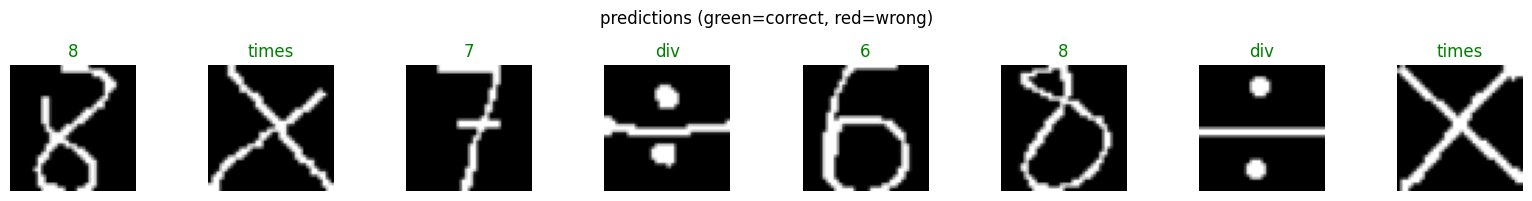

In [ ]:
# quick sanity check, predict on a few val samples
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X_val))
    pred = model.predict(X_val[idx:idx+1], verbose=0)
    pred_label = le.classes_[np.argmax(pred)]
    true_label = le.classes_[np.argmax(y_val[idx])]
    color = 'green' if pred_label == true_label else 'red'
    ax.imshow(X_val[idx].squeeze(), cmap='gray')
    ax.set_title(f'{pred_label}', color=color)
    ax.axis('off')
plt.suptitle('predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.show()

## Copy to project

After training, download `symbol_classifier.h5` and `label_map.json` and put them in the `models/` folder of the project.

In [23]:
from google.colab import files
files.download('symbol_classifier.h5')
files.download('label_map.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>